<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Paired_t_test_Cholestrol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Case Study:**
In the Dixon and Massey data set we have cholesterol levels in 1952 and cholesterol levels in 1962 for each subject. We are interested to check whether there is significant difference in cholesterol levels between these two time points. (The data is available in cholestrol.xlsx)

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read data
df1 = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/cholestrol.xlsx')

# Exploratory Analysis

In [4]:
df1.columns

Index(['Patient', 'chol52', 'chol62', 'age'], dtype='object')

In [5]:
df1.head()                                  # Viewing first few observations of the data

,Patient,chol52,chol62,age
0,1,240,209,35
1,2,243,209,64
2,3,250,173,61
3,4,254,165,44
4,5,264,239,30


In [6]:
df1.describe()                              # Descriptive statistics

,Patient,chol52,chol62,age
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,311.150000,241.350000,44.600000
std,5.91608,64.392934,41.367767,10.884078
min,1.00000,240.000000,165.000000,30.000000
25%,5.75000,275.250000,209.000000,35.000000
50%,10.50000,300.000000,238.500000,44.000000
75%,15.25000,325.750000,271.000000,52.000000
max,20.00000,520.000000,325.000000,64.000000


In [7]:
# Taking difference
df1['errors_diff'] = df1['chol62'] - df1['chol52']
df1['errors_diff'].describe()

,errors_diff
count,20.000000
mean,-69.800000
std,46.563595
min,-195.000000
25%,-90.500000
50%,-67.500000
75%,-31.000000
max,-9.000000


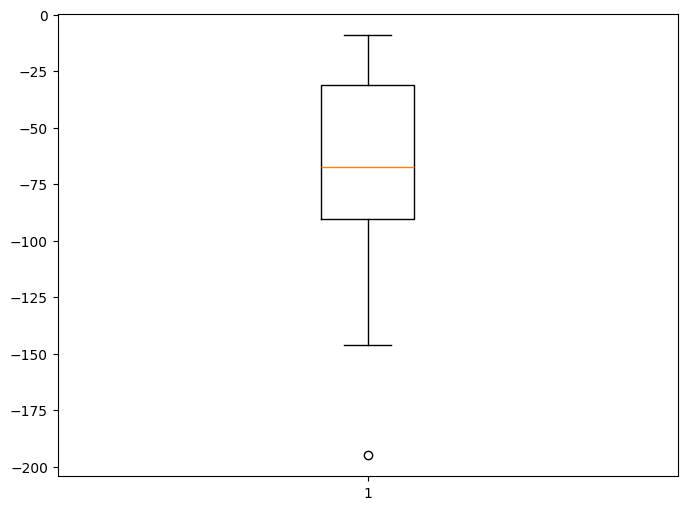

In [8]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df1['errors_diff'])
plt.show()

In [9]:
# Checking Normality using Shapiro test
Shapiro1=stats.shapiro(df1['errors_diff'])
Shapiro1

ShapiroResult(statistic=np.float64(0.9230676491097581), pvalue=np.float64(0.11352705923251966))

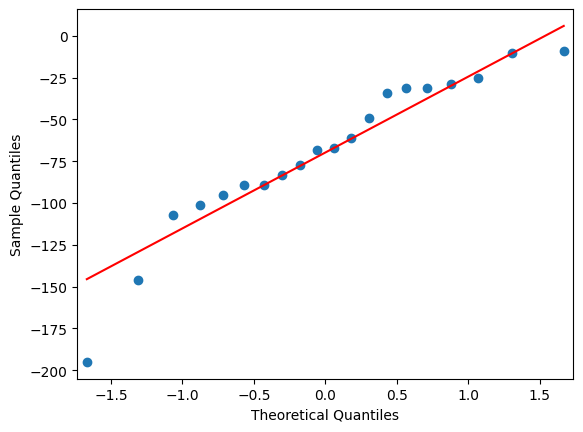

In [10]:
# Checking Normality using Q-Q plot
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

qqplot(df1['errors_diff'],line='s')
plt.show()

In [11]:
# Paired t test / t test for dependent samples

ttest=stats.ttest_rel(df1['chol62'] , df1['chol52'], alternative ='two-sided')
ttest

TtestResult(statistic=np.float64(-6.703844208229617), pvalue=np.float64(2.0809496228289683e-06), df=np.int64(19))

In [12]:
print("Average errors before training:", df1['chol52'].mean())
print("Average errors after training :", df1['chol62'].mean())

Average errors before training: 311.15
Average errors after training : 241.35
